# Complete Exploratory Data Analysis

## Georgia Tech MSA Spring 2026 Pracitcum

## How Teams Create Chances

Our project is focusing on how different teams and competitions create scoring chances, and which possession characteristics are associated with higher-quality shots?

In order to get an understanding of how we can use the statsbomb data to answer this question, we took three main approaches: exploring possession time, exploring heatmaps linked to various activities on the pitch, and logistic regression. 

In [126]:
#Imports
import duckdb
import math
from pathlib import Path
from __future__ import annotations
import warnings
from pathlib import Path
from typing import Any
import polars as pl
import psutil
import matplotlib.pyplot as plt
import re

warnings.filterwarnings("ignore")

#IF NOT INSTALLED THEN INSTALL spatial


# Possession Exploration 

## Explore the distance covered in a given possession

## Data Retrieval 

- The Statsbomb event-level soccer data in Parquet format was our primary data source, accessed using DuckDB SQL queries and Polars lazy dataframes for efficient processing. 
- Project paths were dynamically constructed using Path.cwd() to ensure reproducibility across environments. 

### Assumptions 
- Spatial coordinates accurately represent field locations
- Euclidean distance is a sufficient estimate of ball movement during a possession
- 5 Meters^2 is a sufficient size to divide the pitch for analysis

### Limitations
- Euclidean distance doesn't account for trajectory curvature during ball travel
- Possession timelines were constructed using a single match 

In [127]:
duckdb.sql(f"""INSTALL spatial""")
duckdb.sql(f"""LOAD spatial""")

In [128]:
#gen AI used to generate relative path
current_dir = Path.cwd()
project_root = current_dir.parent
project_location = project_root/"data"

possession_tl = duckdb.sql(f"""
                           LOAD spatial;

                           with match_events as (
                                SELECT id, index_num, period, minute, second, timestamp, duration, location_x, location_y, possession, possession_team_id, type, 
                                    match_id, player_id, position_id, play_pattern, pass_length,
                                CASE WHEN type = 'Carry' THEN 1 ELSE 0 END AS CARRY_IND,
                                CASE WHEN type = 'Pass' THEN 1 ELSE 0 END AS PASS_IND,
                                CASE WHEN type = 'Pressure' THEN 1 ELSE 0 END AS PRESSURE_IND,
                                CASE WHEN type = 'Shot' THEN 1 ELSE 0 END AS SHOT_IND,
                                CASE WHEN type = 'Dribble' THEN 1 ELSE 0 END AS DRIBBLE_IND,
                                CASE WHEN type = 'Dribble Past' THEN 1 ELSE 0 END AS DRIBBLE_PAST_IND,
                                CASE WHEN type = 'Dispossessed' THEN 1 ELSE 0 END AS DISPOSSESS_IND,
                                CASE WHEN type = 'Miscontrol' THEN 1 ELSE 0 END AS MISCONTROL_IND,
                                CASE WHEN type = 'Interception' THEN 1 ELSE 0 END AS INTERCEPTION_IND,
                                CASE WHEN possession_team_id = team_id THEN player_id ELSE NULL END AS possessing_player,
                                CASE WHEN pass_length is NOT NULL THEN 1 ELSE 0 END as pass_attempt_ind,
                                CASE WHEN pass_height = 'High Pass' THEN 1 ELSE 0 END as high_pass_ind,
                                CASE WHEN pass_height = 'Ground Pass' THEN 1 ELSE 0 END as ground_pass_ind,
                                CASE WHEN pass_height = 'Low Pass' THEN 1 ELSE 0 END as low_pass_ind,
                                CASE WHEN pass_body_part = 'Drop Kick' THEN 1 ELSE 0 END as drop_kick_pass_ind,
                                CASE WHEN pass_body_part = 'Head' THEN 1 ELSE 0 END as head_pass_ind,
                                CASE WHEN pass_body_part = 'Keeper Arm' THEN 1 ELSE 0 END as keeper_arm_pass_ind,
                                CASE WHEN pass_body_part = 'Left Foot' THEN 1 ELSE 0 END as left_foot_pass_ind,
                                CASE WHEN pass_body_part = 'Right Foot' THEN 1 ELSE 0 END as right_foot_pass_ind,
                                CASE WHEN pass_body_part = 'Other' THEN 1 ELSE 0 END as other_pass_ind,
                                CASE WHEN pass_technique = 'Inswinging' THEN 1 ELSE 0 END as inswinging_pass_ind,
                                CASE WHEN pass_technique = 'Straight' THEN 1 ELSE 0 END as straight_pass_ind,
                                CASE WHEN pass_technique = 'Through Ball' THEN 1 ELSE 0 END as through_ball_pass_ind



                                FROM read_parquet('{project_location}/Statsbomb/events.parquet') 
                                WHERE match_id = 15973 AND type NOT IN ('Starting XI','Half Start', 'Half End','Ball Receipt*', 'Ball Recovery')
                                AND possession_team_id = team_id
                                AND location_x IS NOT NULL
                                AND location_y IS NOT NULL
                                ),
                                get_next as (
                                SELECT match_events.*, LEAD(location_x,1) OVER (PARTITION BY match_id ORDER BY match_id, index_num) next_location_x, LEAD(location_y,1) OVER (PARTITION BY match_id ORDER BY match_id, index_num) next_location_y
                                FROM match_events
                                ),
                                calc_event_dist as (
                                SELECT get_next.*, ST_Distance(ST_Point(location_x, location_y), ST_Point(next_location_x, next_location_y)) euclidean_distance
                                FROM get_next
                                ),
                                possession_metrics as (
                                SELECT match_id, period, possession, possession_team_id, play_pattern, 
                                    MIN(index_num) min_index, MAX(index_num) max_index,
                                    SUM(IFNULL(duration,0)) total_possession_time, 
                                    SUM(CARRY_IND) carries, 
                                    SUM(PASS_IND) passes, 
                                    SUM(PRESSURE_IND) pressures, 
                                    SUM(SHOT_IND) shots, 
                                    SUM(DRIBBLE_IND) dribbles, 
                                    SUM(DRIBBLE_PAST_IND) dribble_pasts, 
                                    SUM(DISPOSSESS_IND) dispossessions, 
                                    SUM(MISCONTROL_IND) miscontrols,
                                    SUM(INTERCEPTION_IND) interceptions,
                                    SUM(euclidean_distance) total_distance,
                                    COUNT(distinct possessing_player) possessing_players,
                                    SUM(pass_length) pass_distance,
                                    SUM(pass_attempt_ind) pass_attempts,
                                    SUM(high_pass_ind) high_passes,
                                    SUM(ground_pass_ind) ground_passes,
                                    SUM(low_pass_ind) low_passes,
                                    SUM(drop_kick_pass_ind) drop_kick_passes,
                                    SUM(head_pass_ind) head_passes,
                                    SUM(keeper_arm_pass_ind) keeper_arm_passes,
                                    SUM(left_foot_pass_ind) left_foot_passes,
                                    SUM(right_foot_pass_ind) right_foot_passes,
                                    SUM(other_pass_ind) other_passes,
                                    SUM(inswinging_pass_ind) inswinging_passes,
                                    SUM(straight_pass_ind) straight_passes,
                                    SUM(through_ball_pass_ind) through_ball_passes
                                    
                                FROM calc_event_dist

                                GROUP BY match_id, period, possession, possession_team_id, play_pattern
                                ),
                                start_stop_coordinates as (
                                SELECT pm.*, iso_events.location_x poss_start_x, iso_events.location_y poss_start_y, iso_events2.location_x poss_end_x, iso_events2.location_y poss_end_y
                                FROM possession_metrics pm 

                                LEFT JOIN (SELECT id, index_num, location_x, location_y, possession, possession_team_id, match_id
                                            FROM match_events) iso_events
                                    ON pm.match_id = iso_events.match_id
                                    AND pm.possession = iso_events.possession
                                    AND pm.possession_team_id = iso_events.possession_team_id
                                    AND pm.min_index = iso_events.index_num
                                LEFT JOIN (SELECT id, index_num, location_x, location_y, possession, possession_team_id, match_id
                                            FROM match_events) iso_events2
                                    ON pm.match_id = iso_events2.match_id
                                    AND pm.possession = iso_events2.possession
                                    AND pm.possession_team_id = iso_events2.possession_team_id
                                    AND pm.max_index = iso_events2.index_num
                                )

                                SELECT start_stop_coordinates.match_id, start_stop_coordinates.period, start_stop_coordinates.possession, start_stop_coordinates.possession_team_id, play_pattern,
                                    total_possession_time, carries,  passes, pressures, shots, dribbles, dribble_pasts, dispossessions, miscontrols, interceptions, total_distance, possessing_players,
                                    pass_distance, pass_attempts, high_passes, ground_passes, low_passes, drop_kick_passes, head_passes, keeper_arm_passes, left_foot_passes, right_foot_passes, other_passes,
                                    inswinging_passes, straight_passes, through_ball_passes, 

                                ST_Distance(ST_Point(poss_start_x, poss_start_y), ST_Point(poss_end_x, poss_end_y)) relative_distance
                                FROM start_stop_coordinates 
                                ORDER BY possession
                                """)
print(possession_tl)

┌──────────┬────────┬────────────┬────────────────────┬────────────────┬───────────────────────┬─────────┬────────┬───────────┬────────┬──────────┬───────────────┬────────────────┬─────────────┬───────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────┬─────────────┬───────────────┬────────────┬──────────────────┬─────────────┬───────────────────┬──────────────────┬───────────────────┬──────────────┬───────────────────┬─────────────────┬─────────────────────┬────────────────────┐
│ match_id │ period │ possession │ possession_team_id │  play_pattern  │ total_possession_time │ carries │ passes │ pressures │ shots  │ dribbles │ dribble_pasts │ dispossessions │ miscontrols │ interceptions │   total_distance   │ possessing_players │   pass_distance    │ pass_attempts │ high_passes │ ground_passes │ low_passes │ drop_kick_passes │ head_passes │ keeper_arm_passes │ left_foot_passes │ right_foot_passes │ other_passes │ inswinging_passes │ straight_passes │ t

- Only events from match 15973 were analyzed for the possession timeline. 
- Non-gameplay events including: Starting XI, Half Start were excluded. 
- Possesions were restricted to when possension_team_id was equal to the team_id, focusing only on the team with possession

In [129]:
possession_tl = duckdb.sql(f"""SELECT id, index_num, period, minute, second, timestamp,duration, location_x, location_y, possession, possession_team_id, type, 
                                    match_id, player_id, position_id, play_pattern
                                FROM read_parquet('{project_location}/Statsbomb/events.parquet') 
                                WHERE match_id = 15973 AND type NOT IN ('Starting XI','Half Start')
                                AND possession_team_id = team_id
                                
                                """)
print(possession_tl)

┌──────────────────────────────────────┬───────────┬────────┬────────┬────────┬──────────────┬──────────┬────────────┬────────────┬────────────┬────────────────────┬───────────────┬──────────┬───────────┬─────────────┬───────────────┐
│                  id                  │ index_num │ period │ minute │ second │  timestamp   │ duration │ location_x │ location_y │ possession │ possession_team_id │     type      │ match_id │ player_id │ position_id │ play_pattern  │
│               varchar                │   int32   │ int32  │ int32  │ int32  │   varchar    │  float   │   float    │   float    │   int32    │       int32        │    varchar    │  int32   │   int32   │    int32    │    varchar    │
├──────────────────────────────────────┼───────────┼────────┼────────┼────────┼──────────────┼──────────┼────────────┼────────────┼────────────┼────────────────────┼───────────────┼──────────┼───────────┼─────────────┼───────────────┤
│ 4ed11d07-9593-4db1-b0b2-eafe3516700a │         5 │      1 

The posession check data frame evaluates: 
- The non-possession team
- When the possesion type is not Pressure
- Match_id 15973 excluding Starting XI and Half Start Events

In [130]:
possession_check = duckdb.sql(f"""SELECT id, index_num, period, minute, second, timestamp,duration, location_x, location_y, possession, possession_team_id, type, 
                                    match_id, player_id, position_id, play_pattern
                                FROM read_parquet('{project_location}/Statsbomb/events.parquet') 
                                WHERE match_id = 15973 
                                AND type NOT IN ('Starting XI','Half Start')
                                AND possession_team_id != team_id 
                                AND type != 'Pressure'
                                
                                """)

print(possession_check)

┌──────────────────────────────────────┬───────────┬────────┬────────┬────────┬──────────────┬──────────┬────────────┬────────────┬────────────┬────────────────────┬────────────────┬──────────┬───────────┬─────────────┬────────────────┐
│                  id                  │ index_num │ period │ minute │ second │  timestamp   │ duration │ location_x │ location_y │ possession │ possession_team_id │      type      │ match_id │ player_id │ position_id │  play_pattern  │
│               varchar                │   int32   │ int32  │ int32  │ int32  │   varchar    │  float   │   float    │   float    │   int32    │       int32        │    varchar     │  int32   │   int32   │    int32    │    varchar     │
├──────────────────────────────────────┼───────────┼────────┼────────┼────────┼──────────────┼──────────┼────────────┼────────────┼────────────┼────────────────────┼────────────────┼──────────┼───────────┼─────────────┼────────────────┤
│ 7e4ad228-c06c-454f-be40-1542575a9c19 │         9 │

Possesion check2 evaualtes: 
- Match 15973 where the events were not starting XI, Half Start, Pressure or Foul Committed
- Players who affiliated with more than one possession_team_id


In [131]:
possession_check2 = duckdb.sql(f"""
                               with subset_records as (
                               SELECT id, index_num, period, minute, second, timestamp,duration, location_x, location_y, possession, possession_team_id, type, 
                                    match_id, player_id, position_id, play_pattern, team_id
                                FROM read_parquet('{project_location}/Statsbomb/events.parquet') 
                                WHERE match_id = 15973 
                                AND type NOT IN ('Starting XI','Half Start')
                                AND type NOT IN ('Pressure', 'Foul Committed')
                                ),

                                multi_team as (

                                SELECT player_id, COUNT(distinct possession_team_id) 
                                FROM subset_records
                                WHERE match_id = 15973 
                                AND player_id IS NOT NULL
                                GROUP BY player_id
                                HAVING COUNT(distinct possession_team_id) > 1
                                )
                                SELECT *
                                FROM subset_records
                                WHERE player_id IN (SELECT player_id FROM multi_team)
                                AND possession_team_id != team_id
                                """)

print(possession_check2)

┌──────────────────────────────────────┬───────────┬────────┬────────┬────────┬──────────────┬──────────┬────────────┬────────────┬────────────┬────────────────────┬───────────────┬──────────┬───────────┬─────────────┬────────────────┬─────────┐
│                  id                  │ index_num │ period │ minute │ second │  timestamp   │ duration │ location_x │ location_y │ possession │ possession_team_id │     type      │ match_id │ player_id │ position_id │  play_pattern  │ team_id │
│               varchar                │   int32   │ int32  │ int32  │ int32  │   varchar    │  float   │   float    │   float    │   int32    │       int32        │    varchar    │  int32   │   int32   │    int32    │    varchar     │  int32  │
├──────────────────────────────────────┼───────────┼────────┼────────┼────────┼──────────────┼──────────┼────────────┼────────────┼────────────┼────────────────────┼───────────────┼──────────┼───────────┼─────────────┼────────────────┼─────────┤
│ 7e4ad228-c06c-

##


In [132]:
#config
STATSBOMB_DIR = project_root / "data" / "Statsbomb"
WIDTH = 80
TOP_N = 10

# Memory tracking
_process = psutil.Process()
_peak_memory_mb = 0.0


def get_memory_mb() -> float:
    """Get current process memory in MB (RSS - Resident Set Size)."""
    return _process.memory_info().rss / 1024**2


def update_peak() -> float:
    """Update and return peak memory."""
    global _peak_memory_mb
    current = get_memory_mb()
    _peak_memory_mb = max(_peak_memory_mb, current)
    return current


def header(title: str) -> None:
    print("\n" + "=" * WIDTH + f"\n  {title}\n" + "=" * WIDTH)


def mem_report() -> str:
    """Return current and peak memory usage."""
    current = update_peak()
    return f"Memory: {current:.1f} MB (peak: {_peak_memory_mb:.1f} MB)"


def sub(title: str) -> None:
    print(f"\n--- {title} ---")


def dist(lf: pl.LazyFrame, col: str, n: int = TOP_N) -> pl.DataFrame:
    """Print and return distribution for a column."""
    r = (
        lf.group_by(col)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .head(n)
        .collect()
    )
    print(r)
    return r


def desc(lf: pl.LazyFrame, col: str) -> None:
    """Print describe stats for a column."""
    print(lf.select(col).collect()[col].describe())


def top(lf: pl.LazyFrame, cols: list[str], sort_col: str, n: int = TOP_N) -> None:
    """Print top N rows sorted by a column."""
    print(lf.select(cols).sort(sort_col, descending=True).head(n).collect())


def safe_run(func, name: str) -> dict[str, Any] | None:
    """Run analysis with error handling."""
    try:
        return func()
    except FileNotFoundError:
        print(f"\n[SKIP] {name}: File not found")
    except Exception as e:
        print(f"\n[ERROR] {name}: {e}")
    return None

Set up polar dataframes: 
- events.parquet
- lineups.parquet
- matches.parquet
- three_sixty.parquet

In [133]:
tables = {
    "events": pl.scan_parquet(STATSBOMB_DIR / "events.parquet"),
    "lineups": pl.scan_parquet(STATSBOMB_DIR / "lineups.parquet"),
    "matches": pl.scan_parquet(STATSBOMB_DIR / "matches.parquet"),
    "360": pl.scan_parquet(STATSBOMB_DIR / "three_sixty.parquet"),
}

events = tables["events"]
lineups = tables["lineups"]
matches = tables["matches"]
ts = tables["360"]

### Direction Normalization
The logic applied below follows:
In order to understand team orientation per match, answering which team attacks which diection.
Usually the home team attacks left -> right (0->120), and the away team attacks right -> left
Create a team orientation lookup
Use match data to determine home/away, then set attacking direction 

Get unique teams per match with their home/away status

In [134]:
team_orientation = (
    matches
    .select([
        "match_id",
        "home_team_id",
        "home_team",  
        "away_team_id",
        "away_team"   
    ])
    .collect()
)

Create a lookup for each team's attacking direction in each match
Home team: attacks --> goal @ x=120 (left to right)
Away team: attacks --> goal @x=0 (right to left)

One row per team per match

In [135]:
home_teams = (
    team_orientation
    .select([
        "match_id",
        pl.col("home_team_id").alias("team_id"),
        pl.col("home_team").alias("team_name"),  
        pl.lit(1).alias("attacking_direction")  
    ])
)

away_teams = (
    team_orientation
    .select([
        "match_id",
        pl.col("away_team_id").alias("team_id"),
        pl.col("away_team").alias("team_name"),  
        pl.lit(-1).alias("attacking_direction")  
    ])
)

team_direction_lookup = pl.concat([home_teams, away_teams])

print("\nSample of direction mapping:")
print(team_direction_lookup.head(5))


Sample of direction mapping:
shape: (5, 4)
┌──────────┬─────────┬────────────────────────┬─────────────────────┐
│ match_id ┆ team_id ┆ team_name              ┆ attacking_direction │
│ ---      ┆ ---     ┆ ---                    ┆ ---                 │
│ i32      ┆ i32     ┆ str                    ┆ i32                 │
╞══════════╪═════════╪════════════════════════╪═════════════════════╡
│ 9880     ┆ 217     ┆ Barcelona              ┆ 1                   │
│ 9912     ┆ 219     ┆ RC Deportivo La Coruña ┆ 1                   │
│ 9924     ┆ 217     ┆ Barcelona              ┆ 1                   │
│ 9855     ┆ 217     ┆ Barcelona              ┆ 1                   │
│ 9827     ┆ 208     ┆ Las Palmas             ┆ 1                   │
└──────────┴─────────┴────────────────────────┴─────────────────────┘


### Event Processing

In [136]:
events_core = (
    events
    .select([
        "match_id",
        "possession",
        "possession_team_id",
        "team",
        "team_id",  
        "period",   
        "type",
        "minute",
        "second",
        "location_x",
        "location_y",
        "pass_length",
        "pass_angle",
        "pass_cross",
        "pass_through_ball",
        "pass_switch",
        "shot_statsbomb_xg"
    ])
    .with_columns(
        (pl.col("minute") * 60 + pl.col("second")).alias("event_time_sec")
    )
)

print("Core events created")

Core events created


## Join with Direction Information 

Convert to LazyFrame for joining

In [137]:
team_direction_lazy = pl.LazyFrame(team_direction_lookup)

events_with_direction = (
    events_core
    .join(
        team_direction_lazy,
        left_on=["match_id", "team_id"],
        right_on=["match_id", "team_id"],
        how="left"
    )
)


Normalized locations based on attacking direction and period.

Period 1: Use attacking_direction as-is
Period 2: Flip the direction (teams switch sides)


In [138]:
events_normalized = (
    events_with_direction
    .with_columns([
        # Determine effective attacking direction for this period
        pl.when(pl.col("period") == 1)
        .then(pl.col("attacking_direction"))
        .when(pl.col("period") == 2)
        .then(pl.col("attacking_direction") * -1)  # Flip for second half
        .otherwise(pl.col("attacking_direction"))  # Handle extra time if needed
        .alias("effective_direction"),
        
        # Normalize X coordinate so forward is always positive
        # If attacking toward x=120: normalized_x = x (no change)
        # If attacking toward x=0: normalized_x = 120 - x (flip)
        pl.when(
            (pl.col("period") == 1) & (pl.col("attacking_direction") == 1)
        ).then(pl.col("location_x"))
        .when(
            (pl.col("period") == 1) & (pl.col("attacking_direction") == -1)
        ).then(120 - pl.col("location_x"))
        .when(
            (pl.col("period") == 2) & (pl.col("attacking_direction") == 1)
        ).then(120 - pl.col("location_x"))  # Flipped because switched sides
        .when(
            (pl.col("period") == 2) & (pl.col("attacking_direction") == -1)
        ).then(pl.col("location_x"))  # Flipped because switched sides
        .otherwise(pl.col("location_x"))
        .alias("normalized_x")
    ])
)

print("Direction normalization applied")

Direction normalization applied


Possession aggregation

In [139]:
possessions_base = (
    events_normalized
    .group_by([
        "match_id",
        "possession",
        "possession_team_id"
    ])
    .agg([
        pl.count().alias("n_events"),
        pl.min("event_time_sec").alias("possession_start_time"),
        pl.max("event_time_sec").alias("possession_end_time"),
        pl.first("team").alias("team"),
        pl.first("period").alias("period")
    ])
    .with_columns(
        (pl.col("possession_end_time") - pl.col("possession_start_time"))
        .alias("duration_seconds")
    )
)

print("Base possession metrics created.")

events_normalized_sorted = events_normalized.sort(
    ["match_id", "possession", "event_time_sec"]
)

possession_locations = (
    events_normalized_sorted
    .filter(pl.col("normalized_x").is_not_null())
    .group_by([
        "match_id",
        "possession",
        "possession_team_id"
    ])
    .agg([
        pl.first("normalized_x").alias("start_x"),  # Now guaranteed to be first event in time
        pl.first("location_y").alias("start_y"),
        pl.last("normalized_x").alias("end_x"),    # Now guaranteed to be last event in time
        pl.last("location_y").alias("end_y")
    ])
)

possessions = possessions_base.join(
    possession_locations,
    on=["match_id", "possession", "possession_team_id"],
    how="left"
)

possessions = possessions.with_columns([
    (pl.col("end_x") - pl.col("start_x")).alias("forward_progression"),
    # Also calculate absolute for comparison/validation
    (pl.col("end_x") - pl.col("start_x")).abs().alias("total_distance")
])

print("progression calculated using normalized coordinates.")

Base possession metrics created.
progression calculated using normalized coordinates.


Validate the success of normalization 

In [140]:
validation = possessions.select([
    pl.mean("forward_progression").alias("mean_forward_progression"),
    pl.min("forward_progression").alias("min_forward_progression"),
    pl.max("forward_progression").alias("max_forward_progression"),
    pl.mean("start_x").alias("mean_start_x"),
    pl.mean("end_x").alias("mean_end_x"),
]).collect()

print(validation)
print("If normalization worked:")
print("--mean_forward_progression should be slightly positive")
print("--Both teams should show similar patterns")

#addtl. validation: Check if home/away have similar mean progressions
team_progression = (
    possessions
    .join(
        pl.LazyFrame(team_direction_lookup),
        left_on=["match_id", "possession_team_id"],
        right_on=["match_id", "team_id"],  # Key mismatch fix
        how="left"
    )
    .group_by("attacking_direction")
    .agg([
        pl.count().alias("n_possessions"),
        pl.mean("forward_progression").alias("mean_progression"),
    ])
    .collect()
)

print("\nProgression by team type (home=1, away=-1):")
print(team_progression)

home_prog = team_progression.filter(pl.col("attacking_direction") == 1)["mean_progression"][0] if len(team_progression.filter(pl.col("attacking_direction") == 1)) > 0 else None
away_prog = team_progression.filter(pl.col("attacking_direction") == -1)["mean_progression"][0] if len(team_progression.filter(pl.col("attacking_direction") == -1)) > 0 else None

if home_prog is not None and away_prog is not None:
    diff = abs(home_prog - away_prog)
    if diff > 5:
        print(f"\nOOPS: Large difference between home ({home_prog:.2f}) and away ({away_prog:.2f}) progression")
        print("Attacking direction assumption may be incorrect; consider validating with shot locations or manual inspection.")
    else:
        print(f"\nHome/away progression difference is acceptable ({diff:.2f} yards)")
        print("Direction normalization assumption appears valid.")

shape: (1, 5)
┌───────────────────────┬───────────────────────┬──────────────────────┬──────────────┬────────────┐
│ mean_forward_progress ┆ min_forward_progressi ┆ max_forward_progress ┆ mean_start_x ┆ mean_end_x │
│ ion                   ┆ on                    ┆ ion                  ┆ ---          ┆ ---        │
│ ---                   ┆ ---                   ┆ ---                  ┆ f32          ┆ f32        │
│ f32                   ┆ f32                   ┆ f32                  ┆              ┆            │
╞═══════════════════════╪═══════════════════════╪══════════════════════╪══════════════╪════════════╡
│ 0.040853              ┆ -119.300003           ┆ 120.300003           ┆ 59.961128    ┆ 60.00198   │
└───────────────────────┴───────────────────────┴──────────────────────┴──────────────┴────────────┘
If normalization worked:
--mean_forward_progression should be slightly positive
--Both teams should show similar patterns

Progression by team type (home=1, away=-1):
shape: (2, 

Additional Features

In [141]:
possessions = possessions.with_columns([
    #field zones
    (pl.col("end_x") >= 80).alias("ends_in_final_third"),
    (pl.col("end_x") >= 102).alias("ends_in_penalty_box"),
    #starting zone
    (pl.col("start_x") <= 40).alias("starts_in_defensive_third"),
    (pl.col("start_x").is_between(40, 80)).alias("starts_in_middle_third"),
    #progression "intensity"
    (pl.col("forward_progression") >= 20).alias("high_progression"),
    (pl.col("forward_progression") < 0).alias("regressive"),
])

#crossing info
crosses_by_possession = (
    events_normalized_sorted 
    .filter(pl.col("pass_cross") == True)
    .group_by(["match_id", "possession", "possession_team_id"])
    .agg(pl.lit(True).alias("has_cross"))
)

possessions = possessions.join(
    crosses_by_possession,
    on=["match_id", "possession", "possession_team_id"],
    how="left"
).with_columns(
    pl.col("has_cross").fill_null(False)
)

print("tactical features added")

tactical features added


Classifying Possessions 

In [142]:
possessions = possessions.with_columns(
    
    #fast counter-attack: quick, direct, forward
    pl.when(
        (pl.col("duration_seconds") <= 12) &          
        (pl.col("n_events") <= 10) &                  
        (pl.col("forward_progression") >= 40) &   
        (pl.col("forward_progression") > 0)   
    ).then(pl.lit("Fast counter-attack"))

    
    #sustained buildup: "patient" possession  
    .when(
        (pl.col("duration_seconds") >= 30) &
        (pl.col("n_events") >= 20) &
        (pl.col("forward_progression") < 25) &       
        (pl.col("forward_progression") > -10)        
    ).then(pl.lit("Sustained buildup"))

    .when(
        (pl.col("duration_seconds").is_between(12, 30)) &  # Changed from (8, 30)
        (pl.col("forward_progression") >= 20)
    ).then(pl.lit("Transitional attack"))

    
    #wide/crossing play: any possession with cross
    .when(
        pl.col("has_cross") == True
    ).then(pl.lit("Wide / crossing"))


    #regressive possession: moving backward
    .when(
        pl.col("forward_progression") < -5
    ).then(pl.lit("Regressive / defensive"))

    .otherwise(pl.lit("Standard circulation"))
    .alias("possession_type")
)

print("Possession types classified")

Possession types classified


## Possession type distribution 

In [143]:
type_dist = (
    possessions
    .group_by("possession_type")
    .agg([
        pl.count().alias("n_possessions"),
        pl.mean("forward_progression").alias("mean_forward_prog"),
        pl.mean("duration_seconds").alias("mean_duration"),
        pl.mean("n_events").alias("mean_events")
    ])
    .sort("n_possessions", descending=True)
    .collect()
)

print(type_dist)

shape: (6, 5)
┌────────────────────────┬───────────────┬───────────────────┬───────────────┬─────────────┐
│ possession_type        ┆ n_possessions ┆ mean_forward_prog ┆ mean_duration ┆ mean_events │
│ ---                    ┆ ---           ┆ ---               ┆ ---           ┆ ---         │
│ str                    ┆ u32           ┆ f32               ┆ f64           ┆ f64         │
╞════════════════════════╪═══════════════╪═══════════════════╪═══════════════╪═════════════╡
│ Regressive / defensive ┆ 249922        ┆ -41.51144         ┆ 19.874613     ┆ 17.83821    │
│ Standard circulation   ┆ 229171        ┆ 20.101048         ┆ 17.297568     ┆ 14.091246   │
│ Transitional attack    ┆ 82188         ┆ 56.667809         ┆ 19.398574     ┆ 20.464934   │
│ Wide / crossing        ┆ 57157         ┆ -13.61142         ┆ 32.846685     ┆ 30.533111   │
│ Fast counter-attack    ┆ 30790         ┆ 60.021141         ┆ 6.193764      ┆ 5.896038    │
│ Sustained buildup      ┆ 18669         ┆ 7.374985     

## Integrating xG

In [144]:
possession_xg = (
    events_normalized_sorted 
    .filter(pl.col("shot_statsbomb_xg").is_not_null())
    .group_by(["match_id", "possession", "possession_team_id"])
    .agg(
        pl.sum("shot_statsbomb_xg").alias("total_xg"),
        pl.count().alias("n_shots")
    )
)

possessions_with_xg = (
    possessions
    .join(
        possession_xg,
        on=["match_id", "possession", "possession_team_id"],
        how="left"
    )
    .with_columns([
        pl.col("total_xg").fill_null(0),
        pl.col("n_shots").fill_null(0),
    ])
    .with_columns([
        (pl.col("n_shots") > 0).alias("has_shot")
    ])
)

print("xG data integrated")

xG data integrated


# xG by possession type

In [145]:
xg_by_type = (
    possessions_with_xg
    .group_by("possession_type")
    .agg([
        pl.count().alias("n_possessions"),
        pl.mean("has_shot").alias("shot_rate"),
        pl.mean("total_xg").alias("mean_xg_per_possession"),
        pl.sum("total_xg").alias("total_xg"),
        #calculate mean xG only for possessions w/ shots
        pl.col("total_xg")
        .filter(pl.col("has_shot"))
        .mean()
        .alias("mean_xg_given_shot")
    ])
    .sort("mean_xg_per_possession", descending=True)
    .collect()
)

print(xg_by_type)

shape: (6, 6)
┌──────────────────┬───────────────┬───────────┬──────────────────┬─────────────┬──────────────────┐
│ possession_type  ┆ n_possessions ┆ shot_rate ┆ mean_xg_per_poss ┆ total_xg    ┆ mean_xg_given_sh │
│ ---              ┆ ---           ┆ ---       ┆ ession           ┆ ---         ┆ ot               │
│ str              ┆ u32           ┆ f64       ┆ ---              ┆ f32         ┆ ---              │
│                  ┆               ┆           ┆ f32              ┆             ┆ f32              │
╞══════════════════╪═══════════════╪═══════════╪══════════════════╪═════════════╪══════════════════╡
│ Wide / crossing  ┆ 57157         ┆ 0.31158   ┆ 0.041768         ┆ 2387.359863 ┆ 0.134054         │
│ Sustained        ┆ 18669         ┆ 0.141679  ┆ 0.014815         ┆ 276.577667  ┆ 0.104566         │
│ buildup          ┆               ┆           ┆                  ┆             ┆                  │
│ Transitional     ┆ 82188         ┆ 0.139327  ┆ 0.01465          ┆ 1204.0391

## Summary Stats

In [146]:
overall_stats = possessions_with_xg.select([
    pl.count().alias("total_possessions"),
    pl.mean("duration_seconds").alias("mean_duration_sec"),
    pl.mean("n_events").alias("mean_events_per_possession"),
    pl.mean("forward_progression").alias("mean_forward_progression"),
    pl.mean("has_shot").alias("pct_possessions_with_shot"),
    pl.mean("total_xg").alias("mean_xg_per_possession"),
]).collect()

print(overall_stats)

shape: (1, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ total_possessi ┆ mean_duration_ ┆ mean_events_pe ┆ mean_forward_ ┆ pct_possessio ┆ mean_xg_per_p │
│ ons            ┆ sec            ┆ r_possession   ┆ progression   ┆ ns_with_shot  ┆ ossession     │
│ ---            ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           │
│ u32            ┆ f64            ┆ f64            ┆ f32           ┆ f64           ┆ f32           │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 667897         ┆ 20.93883       ┆ 18.249744      ┆ 0.040853      ┆ 0.121267      ┆ 0.014049      │
└────────────────┴────────────────┴────────────────┴───────────────┴───────────────┴───────────────┘


## Heatmaps

Create visual representations of four scenarios:
- The start of shot-ending possessions
- The xG total of an entire possession
- The passes in a possession that ended in a shot
- The successful passes in a a possession that ended in a shot


Create a function to plot an individual heatmap and save the figure

In [147]:
def plot_heat_map(df, value_col, team, title, cmap="hot"):
    #plot outline generated by AI (chatGPT)
    team_df = df.filter(pl.col("team") == team)
    team_df = team_df.group_by(["x_bin", "y_bin"]).agg(pl.col(value_col).mean().alias(value_col))
    pandas_df = team_df.select(["x_bin", "y_bin", value_col]).to_pandas()
    heat_map = (pandas_df.pivot(index="y_bin", columns="x_bin", values=value_col).fillna(0).values)
    plt.figure(figsize=(12,8))
    plt.imshow(heat_map, origin="lower", aspect="auto",cmap=cmap)
    plt.colorbar(label=value_col)
    plt.title(f"{title} - {team}")
    plt.xlabel("Pitch length (x bins)")
    plt.ylabel("Pitch width (y bins)")
    plt.tight_layout()
    plt.savefig(f"{project_root}/figures/{title}_{team}.png", dpi=200, bbox_inches="tight")
    plt.close()  

Create a function to plot an individual heatmap and display the figure

In [148]:
def plot_heat_map_display(df, value_col, team, title, cmap="hot"):
    #plot outlilne generated by AI (chatGPT)
    team = team.strip()
    team = re.sub(r"[\\/]", "_", team)
    team = re.sub(r"[^a-zA-Z0-9._-]", "", team)
    team_df = df.filter(pl.col("team") == team)
    team_df = team_df.group_by(["x_bin", "y_bin"]).agg(pl.col(value_col).mean().alias(value_col))
    pandas_df = team_df.select(["x_bin", "y_bin", value_col]).to_pandas()
    heat_map = (pandas_df.pivot(index="y_bin", columns="x_bin", values=value_col).fillna(0).values)
    plt.figure(figsize=(12,8))
    plt.imshow(heat_map, origin="lower", aspect="auto",cmap=cmap)
    plt.colorbar(label=value_col)
    plt.title(f"{title} - {team}")
    plt.xlabel("Pitch length (x bins)")
    plt.ylabel("Pitch width (y bins)")
    plt.tight_layout()
    plt.show()

Create a function to create heatmaps of a given value for all teams in the statsbomb data

In [149]:
def plot_all_hmaps(df, value_col, title):
    teams = df.select("team").unique().drop_nulls().to_series().to_list()
    for team in teams:
        #regex generated by AI (chatGPT)
        team = team.strip()
        team = re.sub(r"[\\/]", "_", team)
        team = re.sub(r"[^a-zA-Z0-9._-]", "", team)
        plot_heat_map(df, value_col, team, title, cmap="hot")


Prepare the data and plot all the heatmaps for a given scenario by dividing the location into bins, specifically 5 meters.

In [150]:

Bin_Size = 5  # meters
df = pl.read_parquet(STATSBOMB_DIR / "events.parquet")
df = df.with_columns([
    (pl.col("location_x") // Bin_Size).cast(pl.Int64).alias("x_bin"),
    (pl.col("location_y") // Bin_Size).cast(pl.Int64).alias("y_bin"),
])

Prepare the data for plotting in a heatmap, specifically focussing on organizing the position data into shot sequences

In [151]:
#genAI used for syntax
shot_possessions = df.filter(pl.col("type") == "Shot").select(["match_id", "possession"]).unique()
keys = shot_possessions.select(pl.struct(["match_id", "possession"]).alias("key")).to_series()
shot_sequences = df. filter(pl.struct(["match_id", "possession"]).is_in(keys))
shot_sequences_sorted = shot_sequences.sort(["match_id","possession", "minute", "second"])
shot_sequences_binned =shot_sequences_sorted.group_by(["team", "x_bin", "y_bin"]).agg([
    pl.count().alias("events_in_sequence"),
    pl.col("shot_statsbomb_xg").sum().alias("total_xg"),
    pl.col("shot_statsbomb_xg").mean().alias("avg_xg"),
    ])

Create a heatmap of possessions that ended in a shot. These heatmaps are saved in a different folder, but chelsea is displayed as an example. 

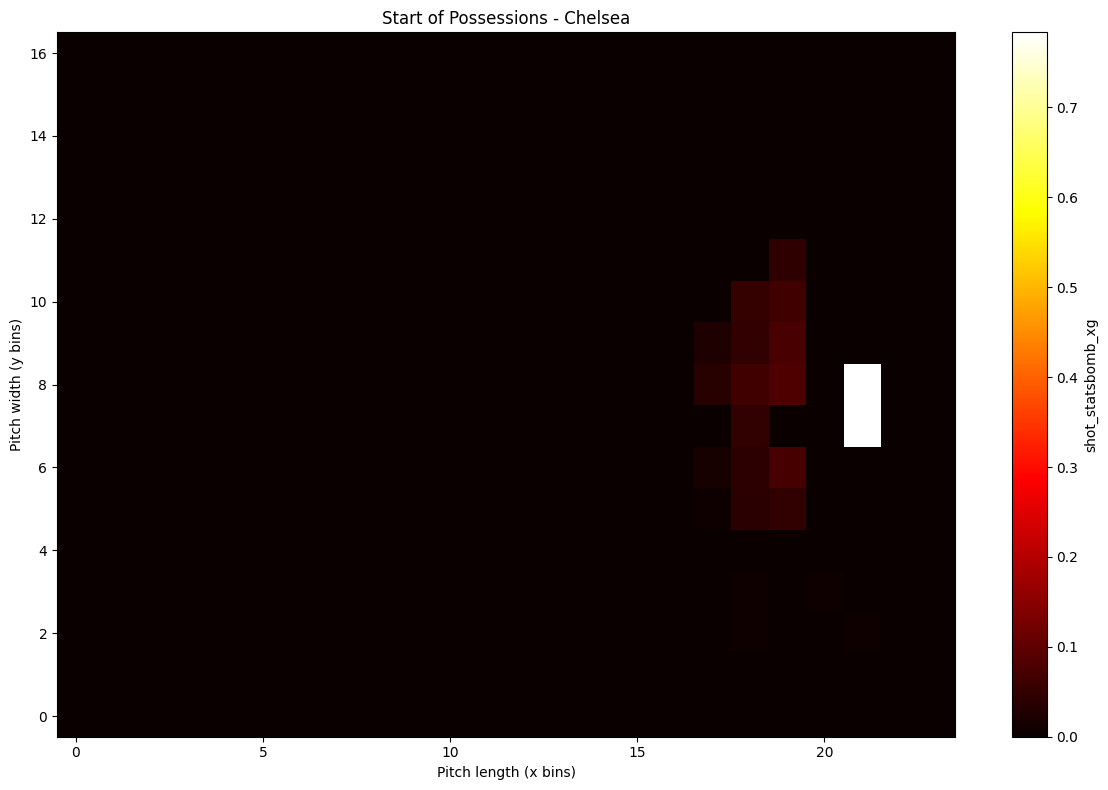

In [152]:
#heatmap of start of shot-ending possessions
possession_starts = shot_sequences.group_by("match_id", "possession").first()
plot_all_hmaps(possession_starts, "shot_statsbomb_xg", "Start of Shot Possessions")
plot_heat_map_display(possession_starts, "shot_statsbomb_xg", "Chelsea", "Start of Possessions" )

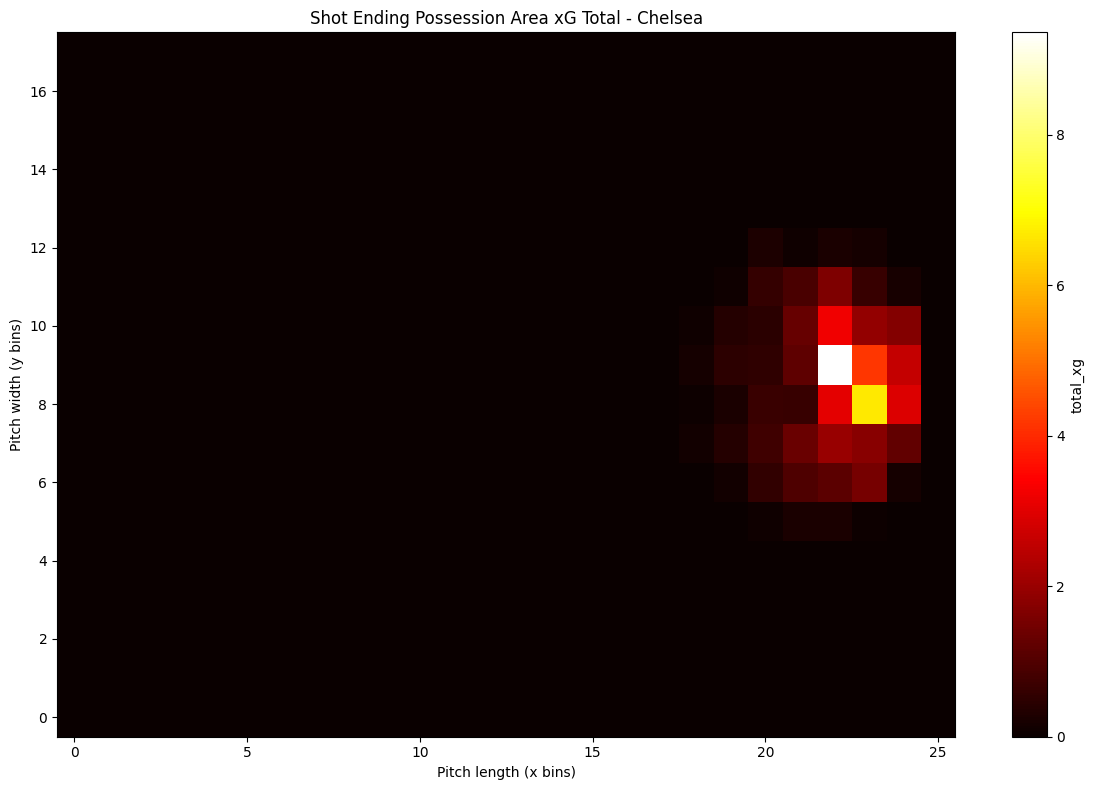

In [153]:
#heatmap of whole possession xg total
plot_all_hmaps(shot_sequences_binned, "total_xg", "Shot Ending Possession Area xG Total")
plot_heat_map_display(shot_sequences_binned, "total_xg", "Chelsea", "Shot Ending Possession Area xG Total" )

In [154]:
#genAI used for syntax
possession_zone_stats = shot_sequences.group_by(["x_bin", "y_bin"]).agg([
    pl.count().alias("events"), 
    pl.col("shot_statsbomb_xg").mean().alias("mean_xg") ,
    pl.col("shot_statsbomb_xg").sum().alias("total_xg")
    ])
possession_zone_stats = possession_zone_stats.drop_nulls("mean_xg")
possession_zone_stats = possession_zone_stats.drop_nulls("total_xg")

print(possession_zone_stats.sort("mean_xg", descending=True))

shape: (237, 5)
┌───────┬───────┬────────────┬──────────┬────────────┐
│ x_bin ┆ y_bin ┆ poss_count ┆ mean_xg  ┆ total_xg   │
│ ---   ┆ ---   ┆ ---        ┆ ---      ┆ ---        │
│ i64   ┆ i64   ┆ u32        ┆ f32      ┆ f32        │
╞═══════╪═══════╪════════════╪══════════╪════════════╡
│ 24    ┆ 7     ┆ 7          ┆ 0.948286 ┆ 1.896572   │
│ 24    ┆ 8     ┆ 11         ┆ 0.639446 ┆ 2.557785   │
│ 23    ┆ 8     ┆ 2995       ┆ 0.443933 ┆ 491.434235 │
│ 23    ┆ 7     ┆ 3098       ┆ 0.440386 ┆ 510.407013 │
│ 21    ┆ 8     ┆ 11902      ┆ 0.315952 ┆ 1451.48291 │
│ …     ┆ …     ┆ …          ┆ …        ┆ …          │
│ 23    ┆ 0     ┆ 933        ┆ 0.000879 ┆ 0.009667   │
│ 23    ┆ 15    ┆ 1071       ┆ 0.00075  ┆ 0.009      │
│ 24    ┆ 16    ┆ 6522       ┆ 0.00018  ┆ 0.00018    │
│ 24    ┆ 15    ┆ 40         ┆ 0.00018  ┆ 0.00054    │
│ 24    ┆ 0     ┆ 5753       ┆ 0.00018  ┆ 0.00054    │
└───────┴───────┴────────────┴──────────┴────────────┘


In [155]:
print(possession_zone_stats.sort("total_xg", descending=True))

shape: (237, 5)
┌───────┬───────┬────────────┬──────────┬────────────┐
│ x_bin ┆ y_bin ┆ poss_count ┆ mean_xg  ┆ total_xg   │
│ ---   ┆ ---   ┆ ---        ┆ ---      ┆ ---        │
│ i64   ┆ i64   ┆ u32        ┆ f32      ┆ f32        │
╞═══════╪═══════╪════════════╪══════════╪════════════╡
│ 21    ┆ 8     ┆ 11902      ┆ 0.315952 ┆ 1451.48291 │
│ 22    ┆ 7     ┆ 12438      ┆ 0.211374 ┆ 928.989807 │
│ 22    ┆ 8     ┆ 12529      ┆ 0.206539 ┆ 916.620789 │
│ 23    ┆ 7     ┆ 3098       ┆ 0.440386 ┆ 510.407013 │
│ 21    ┆ 7     ┆ 10989      ┆ 0.145638 ┆ 499.683197 │
│ …     ┆ …     ┆ …          ┆ …        ┆ …          │
│ 9     ┆ 4     ┆ 5851       ┆ 0.002788 ┆ 0.002788   │
│ 9     ┆ 9     ┆ 5005       ┆ 0.002724 ┆ 0.002724   │
│ 24    ┆ 15    ┆ 40         ┆ 0.00018  ┆ 0.00054    │
│ 24    ┆ 0     ┆ 5753       ┆ 0.00018  ┆ 0.00054    │
│ 24    ┆ 16    ┆ 6522       ┆ 0.00018  ┆ 0.00018    │
└───────┴───────┴────────────┴──────────┴────────────┘


In both total xG and mean xG it can be observed that aproximately the same areas have the most success (x_bin: 21-24, y_bin: 7-8)

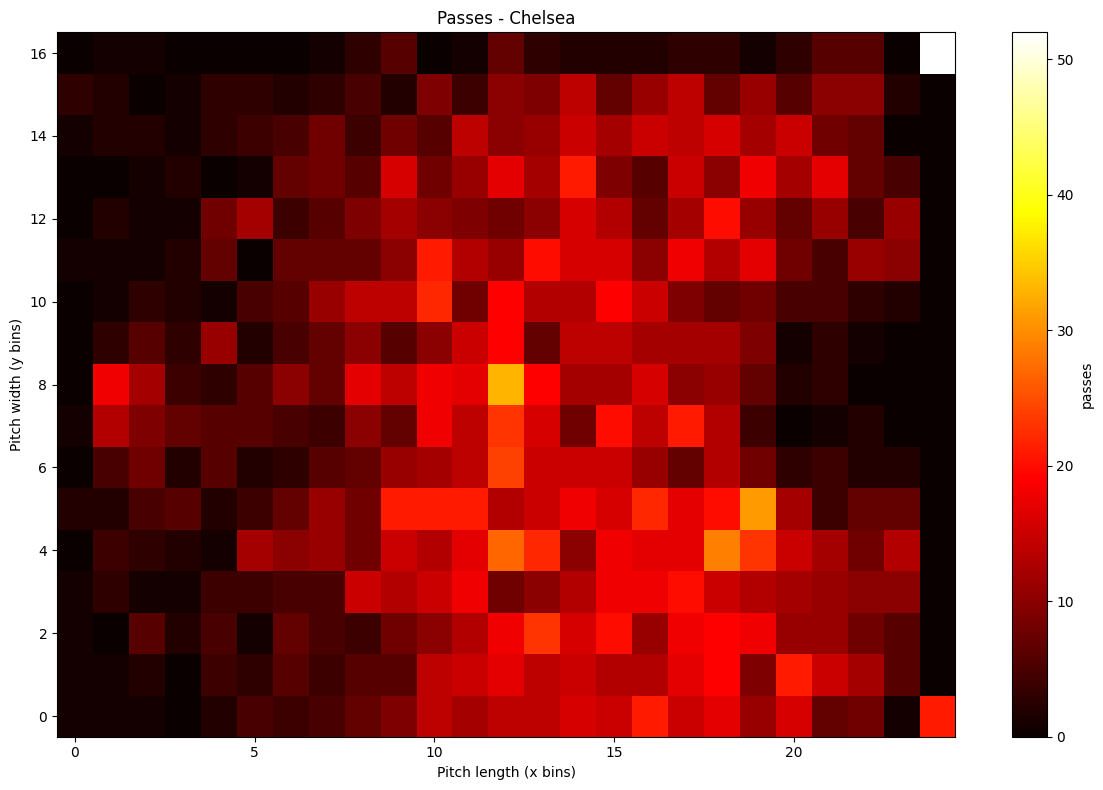

In [156]:
#passes of shot possessions
passes = shot_sequences_sorted.filter(pl.col("type") == "Pass")
pass_spatial = passes.group_by(["team", "x_bin", "y_bin"]).count().rename({"count": "passes"})
# plot_all_hmaps(pass_spatial, "passes", "Passes")
plot_heat_map_display(pass_spatial, "passes", "Chelsea", "Passes" )

In [157]:
#genAI used for syntax
pass_zone_stats = passes.group_by(["x_bin", "y_bin"]).len().rename({"len": "passes"})

print(pass_zone_stats.sort("passes", descending=True))

shape: (424, 3)
┌───────┬───────┬────────┐
│ x_bin ┆ y_bin ┆ passes │
│ ---   ┆ ---   ┆ ---    │
│ i64   ┆ i64   ┆ u32    │
╞═══════╪═══════╪════════╡
│ 24    ┆ 16    ┆ 6521   │
│ 24    ┆ 0     ┆ 5750   │
│ 12    ┆ 8     ┆ 3226   │
│ 1     ┆ 8     ┆ 2553   │
│ 1     ┆ 7     ┆ 2377   │
│ …     ┆ …     ┆ …      │
│ 24    ┆ 10    ┆ 2      │
│ 24    ┆ 12    ┆ 2      │
│ 24    ┆ 9     ┆ 1      │
│ 24    ┆ 1     ┆ 1      │
│ 24    ┆ 7     ┆ 1      │
└───────┴───────┴────────┘


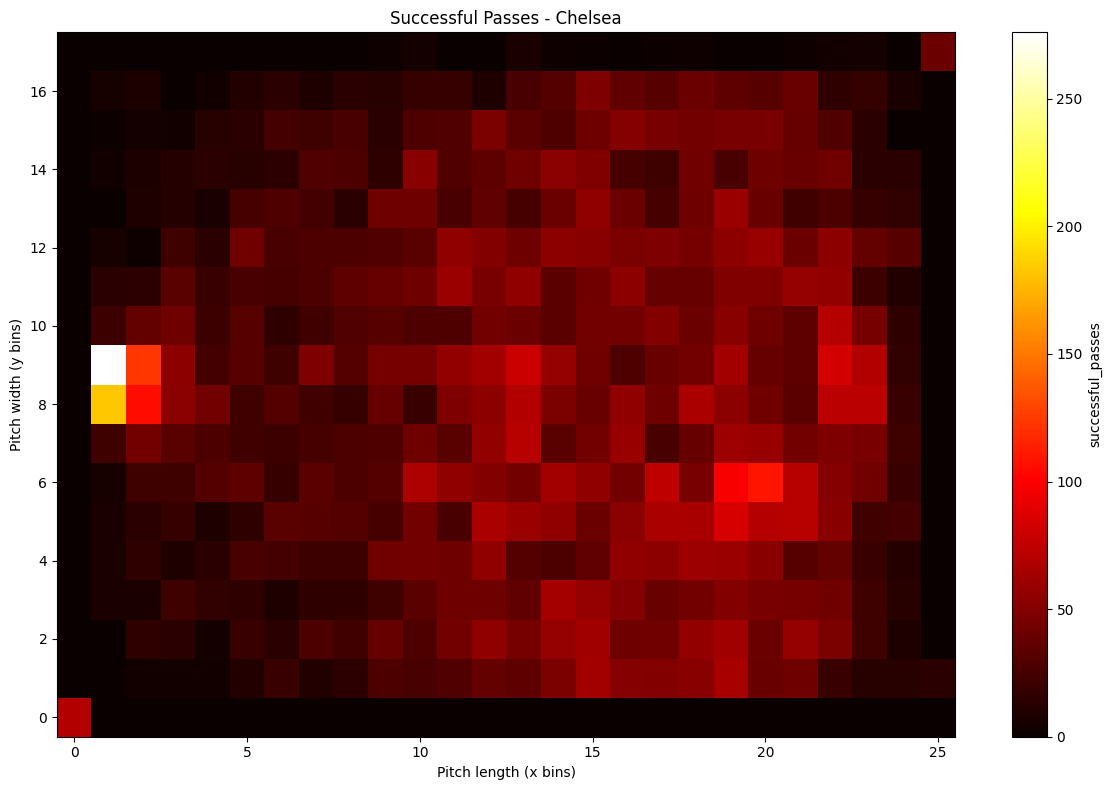

In [158]:
#successfull passes of shot possessions
successful_passes = shot_sequences.filter(pl.col("pass_outcome").is_null().alias("successful"))
pass_successful_spatial = successful_passes.group_by(["team", "x_bin", "y_bin"]).count().rename({"count": "successful_passes"})
plot_all_hmaps(pass_successful_spatial, "successful_passes", "Successful Passes")
plot_heat_map_display(pass_successful_spatial, "successful_passes", "Chelsea", "Successful Passes" )

In [159]:
#genAI used for syntax
pass_zone_stats = successful_passes.group_by(["x_bin", "y_bin"]).len().rename({"len": "successful_passes"})

print(pass_zone_stats.sort("successful_passes", descending=True))

shape: (426, 3)
┌───────┬───────┬───────────────────┐
│ x_bin ┆ y_bin ┆ successful_passes │
│ ---   ┆ ---   ┆ ---               │
│ i64   ┆ i64   ┆ u32               │
╞═══════╪═══════╪═══════════════════╡
│ 0     ┆ 8     ┆ 43247             │
│ 0     ┆ 7     ┆ 36008             │
│ 1     ┆ 8     ┆ 13424             │
│ 1     ┆ 7     ┆ 12891             │
│ null  ┆ null  ┆ 12560             │
│ …     ┆ …     ┆ …                 │
│ 24    ┆ 7     ┆ 7                 │
│ 24    ┆ 10    ┆ 7                 │
│ 24    ┆ 12    ┆ 6                 │
│ 24    ┆ 9     ┆ 4                 │
│ 24    ┆ 14    ┆ 4                 │
└───────┴───────┴───────────────────┘


The bins where more passes are made vs. where more successful passes are made are markedly different. 

## Exports

In [160]:
#saving possessions info
output_path = STATSBOMB_DIR / "possessions.parquet"
possessions_with_xg.collect().write_parquet(output_path)
print(f"Saved possessions info to: {output_path}")

#save summary statistics
summary_path = STATSBOMB_DIR / "possession_type_summary.parquet"
type_dist_with_xg = (
    possessions_with_xg
    .group_by("possession_type")
    .agg([
        pl.count().alias("n_possessions"),
        pl.mean("forward_progression").alias("mean_forward_prog"),
        pl.mean("duration_seconds").alias("mean_duration"),
        pl.mean("n_events").alias("mean_events"),
        pl.mean("has_shot").alias("shot_rate"),
        pl.mean("total_xg").alias("mean_xg"),
    ])
    .sort("mean_xg", descending=True)
    .collect()
)
type_dist_with_xg.write_parquet(summary_path)
print(f"Saved possession type summary to: {summary_path}")

Saved possessions info to: /Users/oliviawesel/Desktop/soccer-analytics-capstone-template/data/Statsbomb/possessions.parquet
Saved possession type summary to: /Users/oliviawesel/Desktop/soccer-analytics-capstone-template/data/Statsbomb/possession_type_summary.parquet
